# Сопоставление с ОДУ
Средний ансамбль из 30 прогонов сопоставляется с RK4 и шагом 0.01.

Row,ode_peak,peak_mean_path,mean_individual_peak,rmse,step_difference
,Float64,Float64,Float64,Float64,Float64
1,158.793,154.767,175.433,1.7653,2.24958e-11


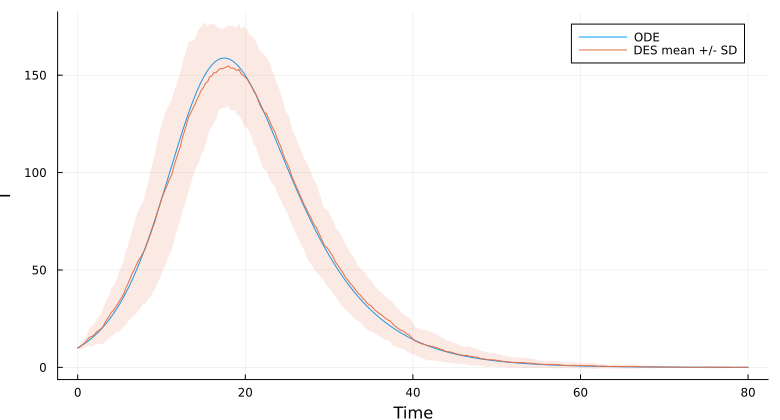

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


function rhs(u)
    flow = 0.05*10*u[1]*u[2]/999
    recovery = 0.25*u[2]
    [-flow,flow-recovery,recovery]
end
function integrate(h)
    u = [990.0,10.0,0.0]
    rows = [(t=0.0,S=u[1],I=u[2],R=u[3])]
    for step in 1:round(Int,80/h)
        a = rhs(u)
        b = rhs(u+h*a/2)
        c = rhs(u+h*b/2)
        d = rhs(u+h*c)
        u += h*(a+2b+2c+d)/6
        step % round(Int,0.25/h) == 0 &&
            push!(rows,(t=step*h,S=u[1],I=u[2],R=u[3]))
    end
    DataFrame(rows)
end
ode = integrate(0.01)
refined = integrate(0.005)
@assert maximum(abs.(ode.I-refined.I)) < 1e-5
@assert maximum(abs.(ode.S+ode.I+ode.R .- 1000)) < 1e-7
result = ensemble(Settings();repeats=30)
summary = DataFrame(ode_peak=[maximum(ode.I)],
    peak_mean_path=[maximum(result.path.mean_I)],
    mean_individual_peak=[mean(result.metrics.peak)],
    rmse=[sqrt(mean((ode.I-result.path.mean_I).^2))],
    step_difference=[maximum(abs.(ode.I-refined.I))])
save_table("ode",ode)
save_table("ensemble",result.path)
save_table("ode_comparison",summary)
display(summary)
figure = plot(ode.t,ode.I,label="ODE",xlabel="Time",ylabel="I")
plot!(figure,result.path.t,result.path.mean_I,
    ribbon=result.path.sd_I,label="DES mean +/- SD",fillalpha=0.15)
savefig(figure,imagefile("ode-comparison"))
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*